# Tarea 1 parte 2: Análisis Exploratorio de Datos

Septiembre 2024

### Introducción
El catálogo SDSS DR18 son datos liberados del Sloan Digital Sky Survey (SDSS), el cual es un proyecto que se dedica a mapear gran parte del cielo en varias longitudes de onda, como veremos durante este estudio, el catalogo incluye información sobre posición, bandas fotométricas, redshift, etc.

#### Objetivos:
- Cargar y describir la muestra.
- Limpiar los Datos.
- Realizar análisis estadístico y correlaciones.
- Visualizar datos.

### Importación de Librerias

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image

%matplotlib inline  
sns.set_style('whitegrid') 

### Carga de los datos

In [2]:
sdss = pd.read_csv('SDSS_DR18.csv')

In [3]:
sdss.head(4)

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1237662268080652961,243.022574,4.385969,19.15551,17.43852,16.77859,16.57280,16.44750,3910,301,4,218,2452361257613813760,STAR,0.000036,2178,54629,550
1,1237661360759046220,195.275753,46.400545,19.38022,18.93722,19.02865,18.82185,18.58639,3699,301,2,69,1642754261953570816,QSO,0.459566,1459,53117,241
2,1237661353778610198,174.481653,57.687130,17.70803,16.86243,16.56471,16.47062,16.46995,3697,301,5,52,7985070817695520768,STAR,-0.000093,7092,56683,686
3,1237662307260039308,206.021591,41.142105,17.38189,15.91817,15.13140,14.71470,14.41762,3919,301,5,32,1550477472590489600,GALAXY,0.060660,1377,53050,412


Como mencionamos anteriormente nuestro catalogo son datos de un survey astronomico: SDSS. Por lo que en sus columnas reflejan las ID ('objid'), las posiciones ('ra', 'dec'), las magnitudes en las bandas (u, g, r, i, z), la clasificación ('class') y el redshift para cada objeto, además la fecha en que fue observado ('mjd') y las demás columnas son las caracteristicas del telescopio. 

De ellas consideramos relevantes la clase ('class') ya que podemos identificar si es una estrella, quasar o una galaxia. Además es importante el redshift, este nos dice que tan lejos se encuentra el objeto de nosotros, se abrevia como z, a un $z$ cercano a $0$ es que está en nuestra galaxia o a sus alrededores.

Ya en más detalles, podemos ver con .info() el nombre de las columnas, si tiene datos vacíos y el tipo de dato.

In [4]:
sdss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  int64  
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  uint64 
 13  class      10000 non-null  object 
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(8), int64(8), object(1), uint64(1)
memory usage: 1.4+ MB


### Valores nulos

Como pudimos ver en la info hay 10 mil datos en las 18 columnas, estos datos son tipo float e int a excepción de 'class' que es un string.

En el conjunto de datos no se presentan valores nulos o faltantes, lo cual simplifica el análisis ya que garantiza que todas las filas y columnas del catálogo están completas.

Igualmente lo podemos rectificar sumando las celdas vacías si es que existen:

In [5]:
sdss.isnull().sum()

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
redshift     0
plate        0
mjd          0
fiberid      0
dtype: int64

Como se puede ver ninguna columna tiene una celda vacía.

### Objetos duplicados

Veremos si existen objetos duplicados en la columna "objid" para no contar 2 veces el mismo objeto y no generar sesgo en el análisis.

In [6]:
conteo = sdss['objid'].value_counts()             # se guarda en 'conteo' todos los id que existen en 'objid'

# si hay un id repetido, entonces estará minimo 2 veces en el conteo,
# por lo que se guardará si se cumple aquella condición.

duplicados = conteo.loc[lambda x: x > 1]          

print(duplicados)

Series([], Name: count, dtype: int64)


Podemos ver que no hay valores que tengan duplicados en la columna  "objid"

### Limpieza del catalogo

De estas 18 columnas, hay 3 que son identificadores: 'objid', 'specobjid' y 'fiberid' (reconocidos porque terminan en _id_). Lo cual consideramos que para identificar cada objeto solo necesitamos 1 variable, así que dejaremos 'objid'.

Solo en caso de que necesitaramos identificarlo, más adelante no se considerará esta variable como estudio ya que el objetivo es ver relaciones de las variables del catalogo mas no identificar a cada galaxia.

In [7]:
sdss= sdss.drop(columns=['specobjid','fiberid'],axis=1);

In [8]:
sdss['rerun'].value_counts()

rerun
301    10000
Name: count, dtype: int64

Además se puede eliminar la columna 'rerun' ya que todos los objetos presentan el mismo valor, es decir que es una caracteristica del catalogo pero no peculiar a cada objeto por lo que no se puede hacer un mayor analisis. Es por ello que también la eliminaremos.

In [9]:
sdss= sdss.drop('rerun',axis=1);

Otro dato que consideramos irrelevante en nuestro estudio es 'mjd', ya que este refiere al día que ha sido tomado el dato. Por lo cual no es un dato del objeto astronomico sino que del telescopio en si, así que por ello también eliminamos esta columna ya que estamos analizando las caracteristicas de los objetos.

In [10]:
sdss= sdss.drop('mjd',axis=1);

También eliminaremos las otras columnas que refieran al telescopio, dado a nuestro enfoque en los entes astronomicos.

In [11]:
sdss= sdss.drop(columns=['run','camcol','field','plate'],axis=1);

### Catalogo resultante

In [12]:
sdss.head(4)

,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237662268080652961,243.022574,4.385969,19.15551,17.43852,16.77859,16.57280,16.44750,STAR,0.000036
1,1237661360759046220,195.275753,46.400545,19.38022,18.93722,19.02865,18.82185,18.58639,QSO,0.459566
2,1237661353778610198,174.481653,57.687130,17.70803,16.86243,16.56471,16.47062,16.46995,STAR,-0.000093
3,1237662307260039308,206.021591,41.142105,17.38189,15.91817,15.13140,14.71470,14.41762,GALAXY,0.060660


Descripción de la muestra escogida:
- **objid**	Es el ID del objeto.
- **ra** (Right Ascension) Ascensión recta del objeto.
- **dec**  (Declination) Declinación del objeto.
- **u**	banda u (ultravioleta) con rango de  [10.99623 - 19.59979].
- **g**	banda g (verde) con rango de [10.51139 - 19.90642].	
- **r**	banda r (rojo) con rango de [9.82207 - 26.79265].
- **i**	banda i (infrarrojo cercano) con rango de [9.469903 - 30.16359]. 
- **z**	banda z (infrarojo) con rango de [9.612333 - 29.38374 ].	
- **class**	Clase/Tipo de objeto observado, pueden ser **STAR**, **QSO**, **GALAXY**.
- **redshift** Corrimiento al rojo del objeto.

### Mapa del SDSS DR18

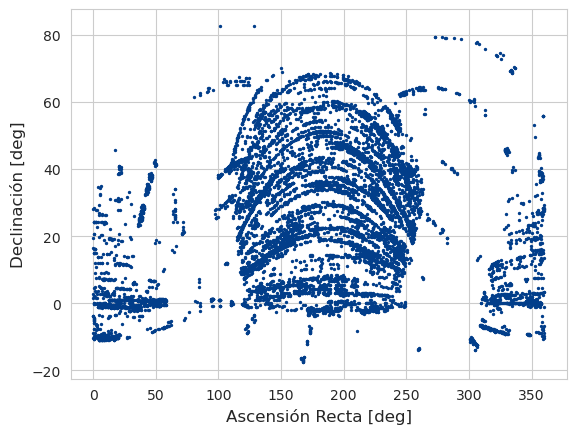

In [13]:
plt.scatter(sdss['ra'],sdss['dec'],s=2,color='#023e8a')
plt.xlabel("Ascensión Recta [deg]", size=12)
plt.ylabel("Declinación [deg]", size=12)
plt.show()

En el grafico anterior se muestra las posiciones de los objetos mapeados por el SDSS a lo cual notamos que en esta version del survey existen lugares menos explorados.

### Posibles outliers

Algunos posibles outliers serían los objetos a redshift lejano ya que como podemos ver a continuación en la relación con una coordenada, todos los datos siguen un patrón y solo 10 de 10000 superan un redshift mayor a 3.

Por lo que después veremos como afecta a la matriz de correlación incorporar o no estos datos. Aunque como premisa son solo el 10/10000 i.e. 0.1% por lo que creemos que no debiese haber diferencias.

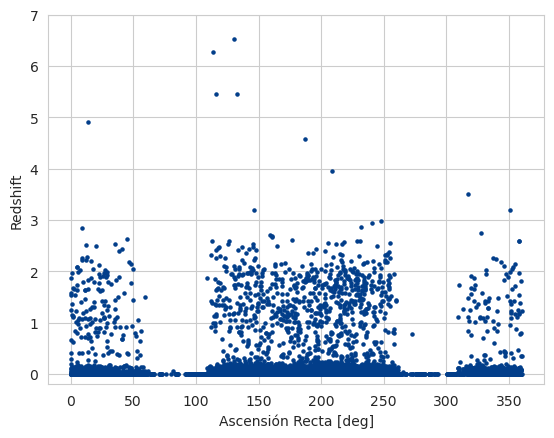

In [14]:
plt.scatter(sdss['ra'],sdss['redshift'],s=5,color='#023e8a')
plt.ylim(-0.2,7)
plt.xlabel('Ascensión Recta [deg]')
plt.ylabel('Redshift')
plt.show()

In [15]:
znear = sdss[sdss['redshift']<=3]      #guardamos en una variable los que esten a z<3

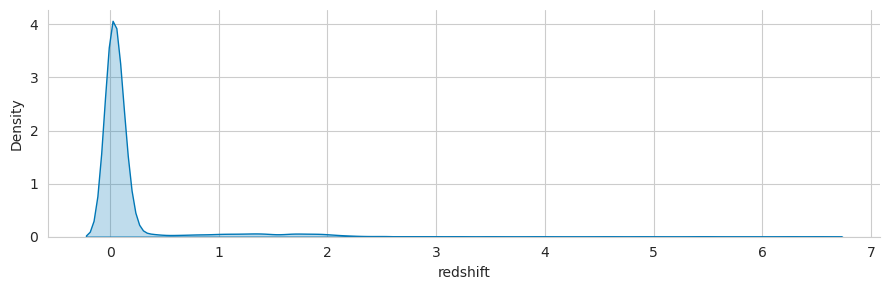

In [16]:
fig1 = sns.FacetGrid(sdss,aspect=3)
fig1.map(sns.kdeplot,'redshift',fill=True,color='#0077b6')

Realizando el grafico de densidad del redshift, nos dimos cuenta de un detalle. En el catalogo existen redshifts negativos.

Por definición el redshift hoy en nuestra galaxia es 0 y a medida que nos alejamos debiese aumentar su valor, por lo que no debiesen existir valores negativos. 

Así que a continuación analizaremos en detalle cuantos valores negativos hay por cada clase y cuales son sus valores y como se podría solucionar.

### Tratamiento del redshift negativo

Lo primero que haremos es crear una copia del catalogo, para después en una función contar cuantas galaxias son a $z<0$ y luego verlas en detalle.

In [17]:
cat = sdss.copy()

In [18]:
def redshift_neg(sdss):
    clases = sdss['class'].unique()
    total_negativos = 0  
    
    for clase in clases:
        negativos = sdss[(sdss['class'] == clase) & (sdss['redshift'] < 0)]     #catalogo con objetos de aquella clase con z<0
        num_negativos = len(negativos)                                          #cantidad de objetos a z<0
        total_negativos += num_negativos                    
        
        if num_negativos > 0:
            print(f"Clase {clase} tiene {num_negativos} valores de redshift negativo.")
        else:
            print(f"Clase {clase} no tiene valores de redshift negativo.")
    print("        ")
    print("En total ",total_negativos, "objetos.")


redshift_neg(sdss)


Clase STAR tiene 2740 valores de redshift negativo.
Clase QSO no tiene valores de redshift negativo.
Clase GALAXY tiene 1 valores de redshift negativo.
        
En total  2741 objetos.


Del catalogo de 10 mil objetos, 2741 tienen redshift negativo en donde casi la totalidad son estrellas. Al ser casi el 30% de la muestra no es recomendable eliminarlos ya que perderíamos datos así que evaluaremos cada clase. Esto se puede deber a que están muy cercas por lo que puede haber error de precisión, lo cual revisaremos viendo el catalogo: 

In [19]:
zneg_star = cat[(sdss['class'] == 'STAR') & (sdss['redshift'] < 0)] 
zneg_star.head(5)

,objid,ra,dec,u,g,r,i,z,class,redshift
2,1237661353778610198,174.481653,57.687130,17.70803,16.86243,16.56471,16.47062,16.46995,STAR,-0.000093
5,1237667782846120008,212.859179,20.153084,18.24440,17.81059,17.98479,18.19268,18.42586,STAR,-0.000094
6,1237662500000170041,224.847712,45.154162,18.60496,17.72086,17.38395,17.27191,17.23877,STAR,-0.000234
10,1237658206124179465,192.392700,50.952396,18.73235,17.25093,16.69400,16.49351,16.42679,STAR,-0.000175
11,1237658206115659817,162.153684,48.934907,16.95651,15.54036,15.01505,14.86540,14.79200,STAR,-0.000089


In [20]:
zneg_star['redshift'].min()      #vemos el valor más cercano a 0 

-0.003808179

Veamos la unica galaxia a $z<0$.

In [21]:
cat[(sdss['class'] == 'GALAXY') & (sdss['redshift'] < 0)]

,objid,ra,dec,u,g,r,i,z,class,redshift
112,1237670961627725920,42.24333,33.655135,18.88195,17.15847,16.33445,16.08377,15.97199,GALAXY,-0.000063


Viendo las primeras 5 estrellas y la galaxia con redshift negativo, notamos que son valores cercanos a 0. La estrella de mayor valor es $z \approx -0.0038$ es decir que si aproximamos los 2741 objetos a dos decimales equivaldrían 0. Aunque el aproximar, en este caso no lo encontramos correcto ya que luego al ver histogramas de distribución no tendremos una buena representación al decir que todos estos valen 0.

Por lo que buscamos información sobre como mide el redshift SDSS $[1]$. El survey mide los espectros y en base a ello con un programa calcula los z, $z$ positivos significa redshift y $z$ negativos significa blueshift.

Con esto nos damos cuenta que hemos tenido una confusión respecto a la definición del redshift. Existe el redshift cosmologico que depende de la expansión del universo y existe el redshift por el efecto Doppler, a lo cual este ultimo es el que calcula SDSS. Por lo que corresponde redshift al objeto que se aleja y blueshift al que se acerca a nosotros.

Así que tenemos una propuesta, en la columna del redshift dejar solo a las que de verdad son redshift y crear una nueva columna con los objetos que sean blueshift. Luego de separarlos, les quitaremos el valor negativo dado que ya están separados por lo que no se necesita el signo representativo.

In [22]:
def blue(columna_z):
    if columna_z < 0:                                   #si z es neg
        return columna_z*-1                             #que se guarde el absoluto
    else:
        return np.nan                                   #si no se cumple, que retorne un vacío-
    
def red(columna_z):
    if columna_z > 0:
        return columna_z
    else:
        return np.nan
    
def marcador(columna_z):
    if columna_z < 0:        
        return 'Blueshift'
    else:
        return 'Redshift'
    
cat['Blueshift'] = cat.apply(lambda x: blue(x['redshift']), axis=1) #lo mismo que la tarea pasada, se crea una nueva columna con los datos que sean blueshift.
cat['Redshift'] = cat.apply(lambda x: red(x['redshift']), axis=1)
cat['Tipo'] = cat.apply(lambda x: marcador(x['redshift']), axis=1)

newcat = cat.drop('redshift',axis=1);

In [23]:
newcat.head(4)

,objid,ra,dec,u,g,r,i,z,class,Blueshift,Redshift,Tipo
0,1237662268080652961,243.022574,4.385969,19.15551,17.43852,16.77859,16.57280,16.44750,STAR,NaN,0.000036,Redshift
1,1237661360759046220,195.275753,46.400545,19.38022,18.93722,19.02865,18.82185,18.58639,QSO,NaN,0.459566,Redshift
2,1237661353778610198,174.481653,57.687130,17.70803,16.86243,16.56471,16.47062,16.46995,STAR,0.000093,NaN,Blueshift
3,1237662307260039308,206.021591,41.142105,17.38189,15.91817,15.13140,14.71470,14.41762,GALAXY,NaN,0.060660,Redshift


Por lo que ahora para cada objeto tenemos 10 columnas. A continuación realizaremos un analisis descriptivo de estos datos para estudiar las caracteristicas de este catalogo.

### Analisis descriptivo

In [24]:
des = newcat.describe()                      #con .describe() podemos obtener varias medidas estadisticas
des = des.drop('count',axis=0);              #eliminamos 'count' ya que ya sabemos la cantidad que tenemos en cada columna
des = des.drop('25%',axis=0);                
des = des.drop('75%',axis=0);                #también eliminamos 25 y 75%, para concentrarnos en el minimo, la media (50%) y el maximo.
des = des.drop('objid',axis=1);              #no tiene sentido aplicar mediciones en un identificador.
des

,ra,dec,u,g,r,i,z,Blueshift,Redshift
mean,179.274151,24.088531,18.638108,17.426811,16.914705,16.668606,16.519843,3.085762e-04,2.450693e-01
std,83.675127,20.154348,0.830792,0.982355,1.132658,1.216107,1.304670,3.046260e-04,5.240924e-01
min,0.075739,-17.465391,10.996230,10.511390,9.822070,9.469903,9.612333,1.718484e-07,1.894666e-07
50%,184.949583,23.801733,18.874355,17.525205,16.923505,16.626970,16.463615,2.023151e-04,7.022155e-02
max,359.999615,82.656319,19.599790,19.906420,26.792650,30.163590,29.383740,3.808179e-03,6.517635e+00


Recordemos que la posición está definida por "ra" y "dec", gracias a la tabla podemos decir que la media de la posición es 179.27 grados para "ra" y 24.09 grados para "dec". Nos llama la atención la gran dispersión en "ra" (std = 83.675127) esto nos indica que los valores se extienden en un rango amplio de valores. Respecto a las bandas, la desviación es menor en comparación a "ra" y "dec". En relación al Redshift, el promedio es de 0.245, es decir, en promedio el 70% de los objetos de nuestro catálogo se alejan con resdhift z = 0.245, en cambio, si nos fijamos en el Blueshift, en promedio, el 30% de los objetos se están acercando con z=- 3.085762e-04. Ahora, si nos fijamos en los valores extremos del redshift podemos ver que el máximo es de 6.5576 y el mínimo es de 1.89e-07 , lo que quiere decir que en nuetro catálogo hay objetos que están alejandose muy rápido y están extremadamente distantes y objetos que están muy cercanos.

### Caracterización de la muestra 

In [25]:
distribucion_cz = newcat.groupby('class')['Tipo'].value_counts()
df_cz = distribucion_cz.reset_index(name='Count')
distribucion_cz

class   Tipo     
GALAXY  Redshift     4760
        Blueshift       1
QSO     Redshift     1109
STAR    Blueshift    2740
        Redshift     1390
Name: count, dtype: int64

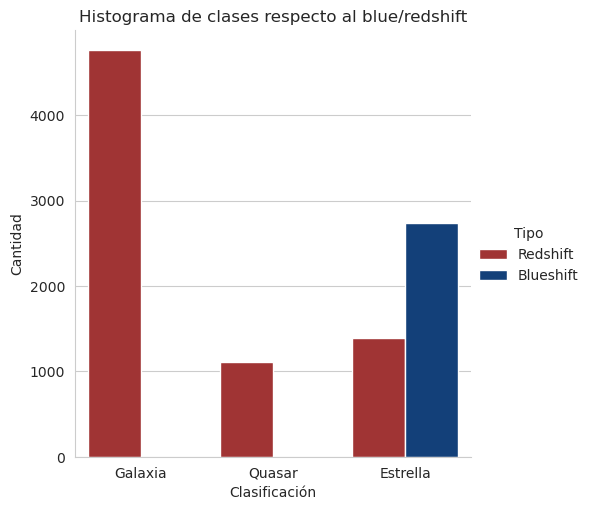

In [26]:
#sns.catplot(data=sdss, x='class',kind='count')
colors = {"Redshift": "firebrick", "Blueshift": "#023e8a"}
sns.catplot(data=df_cz, x='class', y='Count', hue='Tipo', kind='bar', palette=colors)

xlabel = ['Galaxia', 'Quasar', 'Estrella']
plt.xticks(ticks=range(len(xlabel)),labels=xlabel)
plt.xlabel("Clasificación")
plt.ylabel("Cantidad")
plt.title('Histograma de clases respecto al blue/redshift')
plt.show()

El gráfico anterior nos muestra la caracterización de nuestro catálogo, siendo mayoritariamente compuesto de galaxias, existiendo 4761 en total.

Lo que más destaca en la figura es la composición de las estrellas, donde se muestra que la mayoría son blueshift. Por lo que de las 3 clasificaciones, las estrellas son las únicas que están acercandose hacia nosotros.

Por último tenemos a la clase de los QSO (Cuásares) que son los menos numerosos, esto puede ser porque son objetos de naturaleza más extraña que las estrellas y las galaxias.

### Histogramas

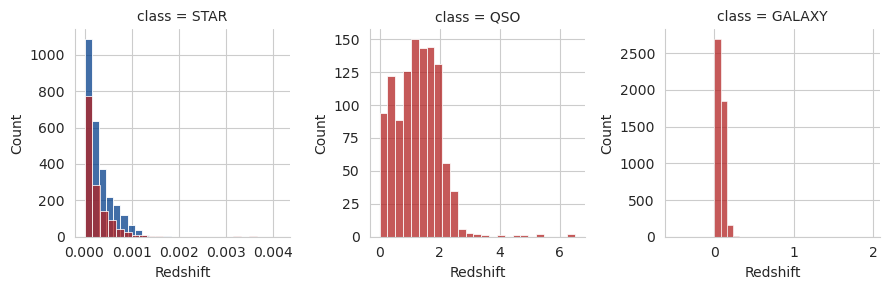

In [27]:
fig = sns.FacetGrid(newcat, col='class', col_wrap=3, sharex=False , sharey=False)
fig.map(sns.histplot, 'Blueshift', bins=25, color='#023e8a')
fig.map(sns.histplot, 'Redshift', bins=25, color='firebrick')

De los histogramas podemos evidenciar que redshift tiene cada clase. Las estrellas están a un redshift cercano ($z<0.002$), las galaxias también están cerca de nosotros ($z<0.5$), en cambio, en los cuasares se puede ver una fluctuación de z entre 0 a 6, por lo que estos se encuentran en zonas más lejanas que las otras clases. 

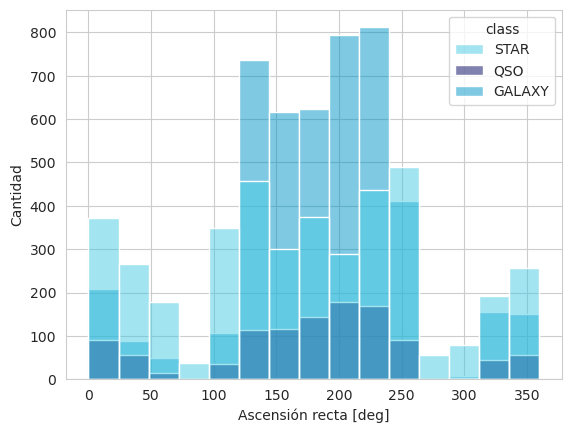

In [28]:
colors2 = {"STAR": "#48cae4", "QSO": "#03045e", "GALAXY": "#0096c7"}

sns.histplot(data=newcat, x='ra', hue='class', bins=15, palette = colors2)
plt.xlabel("Ascensión recta [deg]")
plt.ylabel("Cantidad")
plt.show()

La ascensión recta es una de las dos coordenadas del sistema de coordenadas ecuatoriales (la otra es la declinación) que los astrónomos utilizan para definir las posiciones de los objetos celestes en el cielo. Se mide en horas, donde 360° equivale a 24 horas, por lo que cada hora equivale a 15 grados.

De la distribución podemos decir que no es uniforme, lo cual rectifica los vacíos del mapa que mostramos al inicio, es por ello que también podemos observar que hay una cobertura amplia pero desigual del cielo. Además podemos ver que todas las clases presentan mayor densidad en los valores de asensión recta entre [100 - 250], siendo más espécificos, la clase "GALAXY" presenta dos picos de alta densidad, uno en 140 y otro en 225, los "QSO" presentan un pico en 210 y "STAR" presentan dos picos de densidad, uno en 125 y el otro en 240

Ya como último comentario, no se distingue una preferencia de ascensión recta para cada clase, todas siguen la misma tendencia.

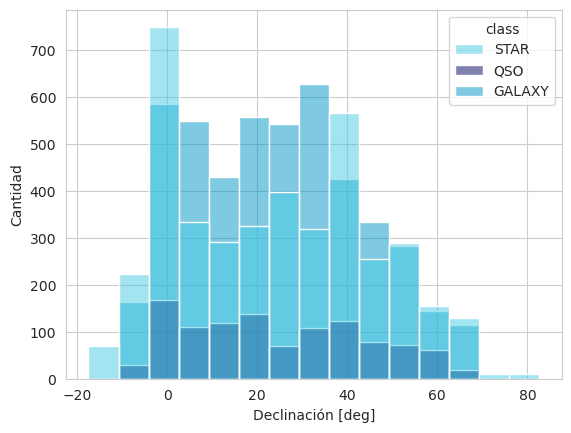

In [29]:
sns.histplot(data=newcat, x='dec', hue='class', bins=15, palette = colors2)
plt.xlabel("Declinación [deg]")
plt.ylabel("Cantidad")
plt.show()

El ángulo de declinación es el ángulo que forma un astro con el ecuador celeste. La declinación se mide en grados sexagesimales, es de norte a sur y se mide en grados; el ecuador es el grado 0, el polo norte el grado 90 y el polo sur el grado -90.

Podemos ver que este histograma de la declinación muestra asimetría, y hay un mayor número de objetos que se encuentran en la declinación 0 (Ecuador celeste). En el histograma también destaca la poca cantidad de objetos con delcinaciones negativas, sugiriendo que no se observó tanto en el hemisferio sur en comparación con el hemisferio norte.

In [30]:
bandas = ['u','g','r','i','z']

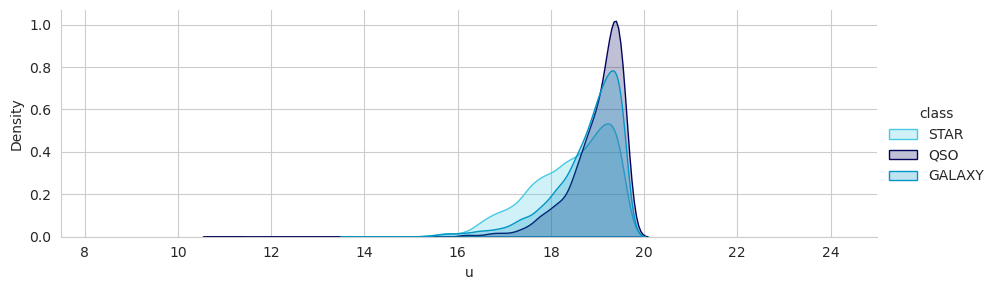

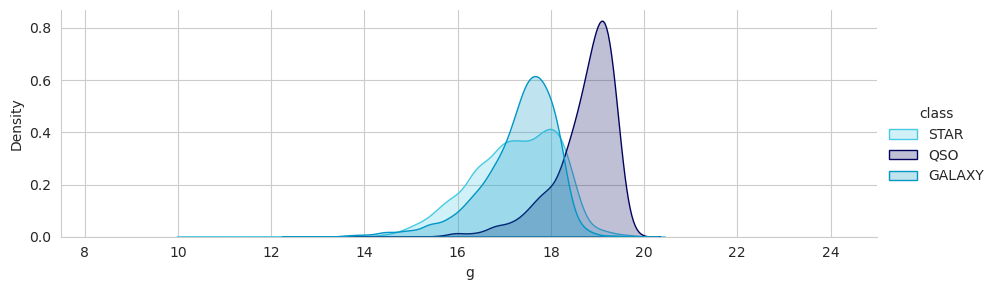

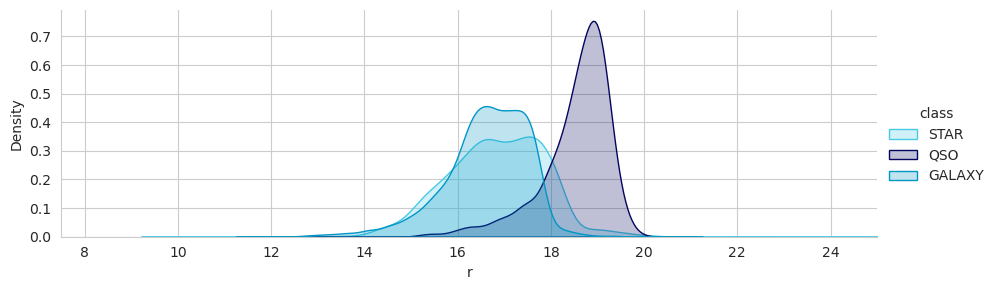

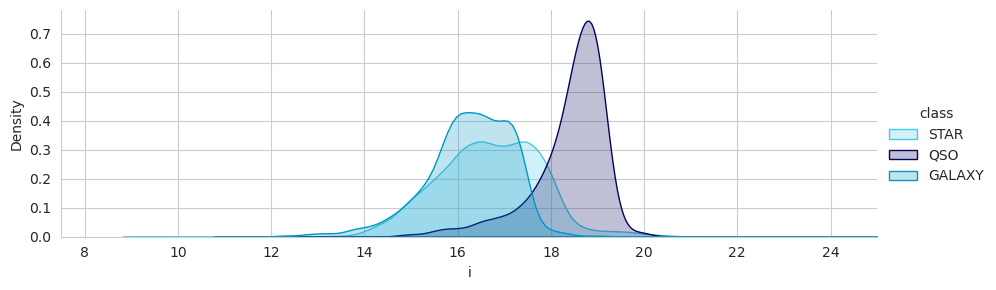

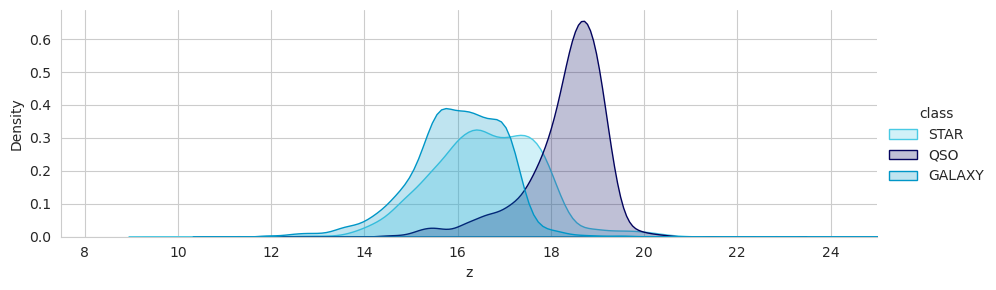

In [31]:
for b in bandas:
    as_fig = sns.FacetGrid(newcat,hue='class',palette = colors2,aspect=3)   #el catalogo se divide en colores para las 3 clases
    as_fig.map(sns.kdeplot,b,fill=True)                      
    oldest = sdss[b].max()
    as_fig.set(xlim=(7.5,25))
    as_fig.add_legend()

Al crear densidades de cada columna que representa a una magnitud en una banda fotometrica, es genial dividirlo por clase ya que se puede ver que los cuasares (QSO) se ven pocos afectados por la banda elegida ya que la concentración casi siempre está en $m \approx 19$.

En cambio, a medida que la banda va de más azul a más rojo (u --> z) podemos notar que las estrellas y las galaxias se ven afectadas por la banda elegida y a más rojiza van teniendo una menor magnitud.

### Correlación de los datos

La correlación de datos es una ecuación matematica que se usa para relacionar 2 variables. Si vale 1 significa que son directamente proporcionales, si es 0 entonces no hay correlación y si vale -1 entonces es inversamente proporcional. 

A partir de esto no se puede decir que uno causa al otro, ya que no mide causalidad. Pero igual nos sirve para tener una idea de como se relacionan las variables, así que a continuación mediremos la correlación con .corr() pero como es un calculo no se aceptan strings así que para tener en cuenta la clase le asignaremos un numero a cada una.

In [32]:
def asignar_num(tipo):
    if tipo == 'STAR':
        return 1
    if tipo == 'QSO':
        return 2
    if tipo == 'GALAXY':
        return 3
    
newcat['tipo'] = newcat.apply(lambda x: asignar_num(x['class']), axis=1)

In [33]:
values = newcat.copy()
values = values.drop(columns=['objid','class','Tipo'],axis=1);    #eliminamos los strings

<AxesSubplot: >

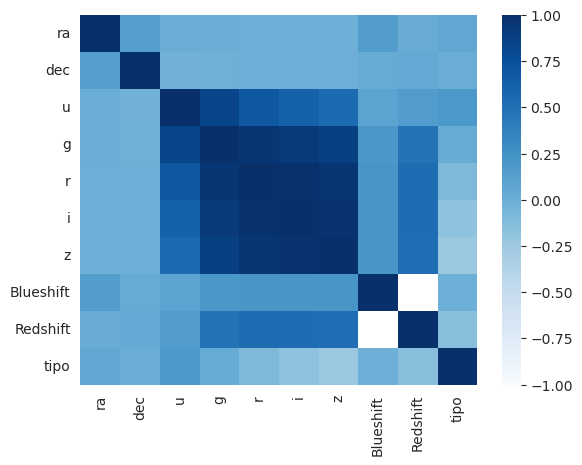

In [34]:
corr = values.corr()
sns.heatmap(corr,cmap = 'Blues', vmin = -1, vmax = 1)

En el mapa de correlación de arriba se puede ver que las magnitudes de las bandas son las que presentan mayor correlación entre sí (tienen colores más azul oscuro, i.e. $\approx 1$). Además también se puede ver una fluctuación entre las bandas y el redshift, por lo que podemos ver los valores en el DataFrame 'corr':

In [35]:
corr

,ra,dec,u,g,r,i,z,Blueshift,Redshift,tipo
ra,1.000000,0.145823,0.010830,0.006109,-0.002194,-0.006995,-0.014771,0.149974,0.021445,0.069767
dec,0.145823,1.000000,-0.030671,-0.020413,-0.013895,-0.009748,-0.006920,0.030446,0.043615,0.008925
u,0.010830,-0.030671,1.000000,0.840908,0.692000,0.611434,0.554356,0.094519,0.163641,0.191123
g,0.006109,-0.020413,0.840908,1.000000,0.958759,0.915225,0.880203,0.196880,0.476942,0.030948
r,-0.002194,-0.013895,0.692000,0.958759,1.000000,0.982074,0.956737,0.214752,0.528602,-0.097576
i,-0.006995,-0.009748,0.611434,0.915225,0.982074,1.000000,0.973607,0.216751,0.530943,-0.179324
z,-0.014771,-0.006920,0.554356,0.880203,0.956737,0.973607,1.000000,0.216224,0.522209,-0.231043
Blueshift,0.149974,0.030446,0.094519,0.196880,0.214752,0.216751,0.216224,1.000000,NaN,-0.015411
Redshift,0.021445,0.043615,0.163641,0.476942,0.528602,0.530943,0.522209,NaN,1.000000,-0.147516
tipo,0.069767,0.008925,0.191123,0.030948,-0.097576,-0.179324,-0.231043,-0.015411,-0.147516,1.000000


Del dataframe se puede confirmar ambas cosas:

- Las bandas **u** **g** **r** **i** **z**, tienen una alta correlación entre ellas y esto tiene sentido ya que miden magnitudes.
- El Redshift presenta una correlación moderada respecto a las bandas **u** **g** **r** **i** **z**, de entre 0.16 a 0.53, lo cual sugiere que existe una relación pero todavía no se puede asegurar al no ser cercano a 1, lo mismo podemos decir del BLueshift.
- "ra" y "dec" no tienen una relación muy fuerte.
- La variable tipo y su correlación con las bandas parece indicar que no están fuertemente relacionados (lo mismo pasa entre la variable tipo y las de posición).



Además notamos valores negativos en las bandas **r** **i** **z** respecto al tipo, que es la clasificación de estrellas, galaxias y quasares. 

### Boxplot

<AxesSubplot: xlabel='dec', ylabel='class'>

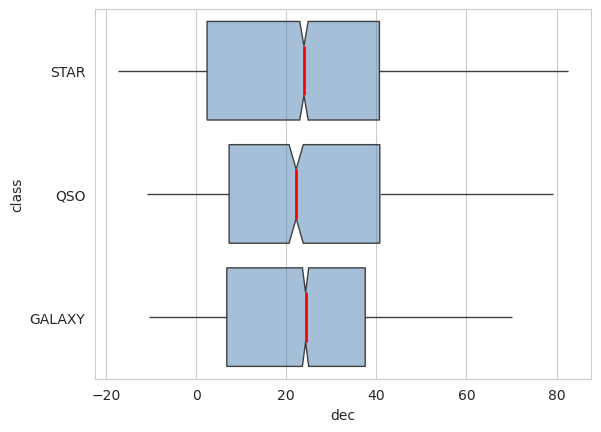

In [36]:
sns.boxplot(
    data=sdss, x="dec", y="class",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

<AxesSubplot: xlabel='ra', ylabel='class'>

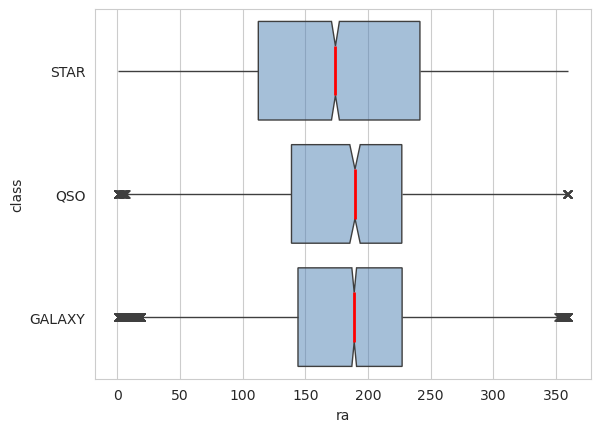

In [37]:
sns.boxplot(
    data=sdss, x="ra", y="class",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

<AxesSubplot: xlabel='redshift', ylabel='class'>

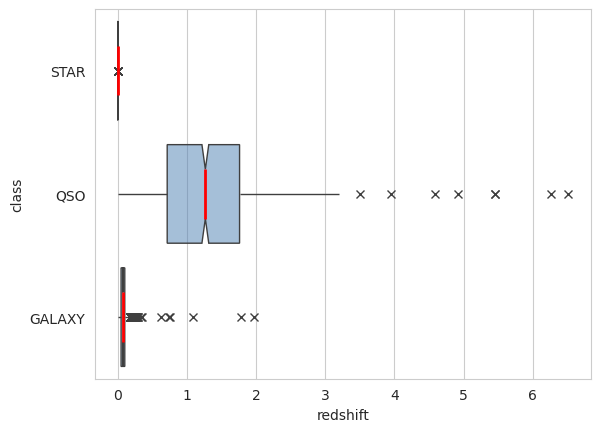

In [38]:
sns.boxplot(
    data=sdss, x="redshift", y="class",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

<AxesSubplot: xlabel='u', ylabel='class'>

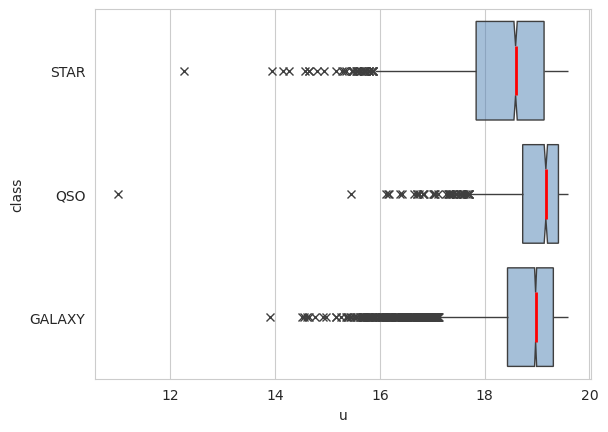

In [39]:
sns.boxplot(
    data=sdss, x="u", y="class",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

<AxesSubplot: xlabel='z', ylabel='class'>

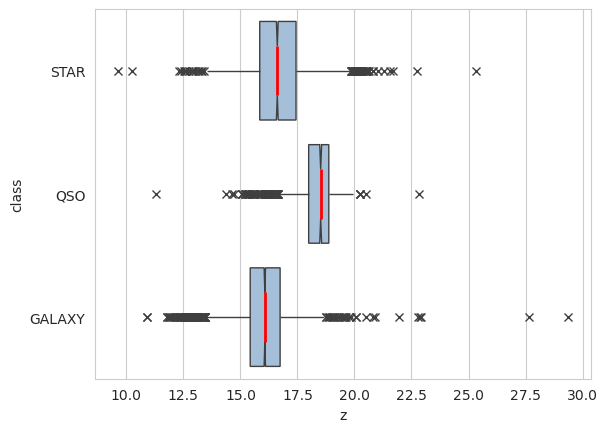

In [40]:
sns.boxplot(
    data=sdss, x="z", y="class",
    notch=True, showcaps=False,
    flierprops={"marker": "x"},
    boxprops={"facecolor": (.3, .5, .7, .5)},
    medianprops={"color": "r", "linewidth": 2},
)

En los gráficos de tipo Boxplot, podemos decir que:

- En la declinación no tenemos outliers.
- Como ya mencionamos, estrellas y galaxias tienen redshift cercano a 0.
- Se presentan varios outliers en el Blueshift de "STAR".
- En el Redshift y "ra" de "QSO" y "GALAXY" también podemos ver varios outliers.
- En blueshift, "STAR" también presenta varios outaliers.

### Conclusión 

Podemos conlcuir que la información obtenida del data set se centraba en los objetos celestes "STAR" y "GALAXY" siendo "QSO" los datos de menor densidad, esto es porque los "QSO" son objetos extraños, dificiles de observar. Respecto a los datos podemos decir que las bandas fotométricas muestran una alta correlación por medir lo mismo, magnitud.

En relación a una futura investigación relacionada al Machine Learning, podriamos utilizar la información de las bandas para inferir el corrimiento al rojo, en lugar de depender de un espectro el cual es muy costoso y de disponibilidad limitada. Entonces con un arbol de decisión se podría hacer un catalogo de entrenamiento y probar después con el de prueba para ver si dio buenos redshift con metricas de evaluación (accuracy, precision y las demás).



## Bibliografía

- $[1]$  https://cas.sdss.org/dr6/en/proj/basic/universe/redshift.asp

- $[2]$ Andrés Almeida et al 2023 ApJS 267 44, The Eighteenth Data Release of the Sloan Digital Sky Surveys: Targeting and First Spectra from SDSS-V.

- $[3]$ https://seaborn.pydata.org/generated/seaborn.boxplot.html
- $[4]$https://www.astro4edu.org/es/resources/glossary/term/286/
- $[5]$Krishna Chunduri (2023), Deep Learning Approach to Photometric Redshift Estimation.